#### Name: 

# PHYS 230 Lab Assignment 15

### Wednesday, April 1, 2026: Chapter 8.2-8.3
- Multivariable differential equations
- Second-order differential equations 

In [94]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a second-order ordinary differential equation for a simple harmonic oscillator. The standard equation is given as: 

$$\frac{d^2x}{dt^2}= -\omega^2 x $$

The general solution to this differential equation is: 

$$x(t) = c_1 \cos \omega t + c_2 \sin \omega t $$

where $c_1$ and $c_2$ can be found from initial conditions. 

For this problem, we will analyze the case of $\omega = 1$ in the range of $t=0$ to $t=50$. The initial conditions are $x=1$ and $dx/dt = 0$. 

*Problem adapted from Exercise 8.6 in the textbook*

### Part 1: Solving the second-order differential equation 

Let's solve for $x$ as a function of time. Do this in the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. 
*Double-check with the professor before moving on.*

\begin{align*}
    \frac{dx}{dt}&=v\\
    \frac{dv}{dt}&=-\omega^2 x
\end{align*}

In [ ]:
#See markdown above

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1. 

In [ ]:
# Diff. Equation
def f(r,t):
    # r = [x,v] // input
    x,v = r[0],r[1]
    
    #Differential equations
    fx = v
    fv = -omega**2 * x
    
    #return f(r,t) = <fx,fv> //  output
    return np.array([fx,fv], float)

#### Step 3: Write a function `RK4_multi(r,t,h,f)` - like you did in the last lab - that you can use to solve any two simultaneous single-order differential equations.  

In [ ]:
# RK4 Function
def RK4(r,t_array,h,f):
    #Output Array we update in for loop
    r_array = np.zeros((len(t_array),2))
    
    #For loop to iterate over each time value
    for i in range(len(t_array)):
        #xpts[i] = x0
        r_array[i] = r
        #k = h*f(r        t               )
        k1 = h*f(r,       t_array[i]      )
        k2 = h*f(r + k1/2,t_array[i] + h/2)
        k3 = h*f(r + k2/2,t_array[i] + h/2)
        k4 = h*f(r + k3,  t_array[i] + h  )
        r += (k1 +2*k2 +2*k3 + k4)/6
    return r_array

#### Step 4: Define any constants and arrays necessary for the problem and solve for $x$ and $dx/dt$ as a function of time. 

In [ ]:
#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 50
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)
r = np.array([1,0], float) #Initial condition
r_array_ho = RK4(r,t_array,h,f) #Output // Results


#### Step 5: Make a plot the position $x$ vs. time. Does this agree with what you expected (add a markdown cell explaining this)? 

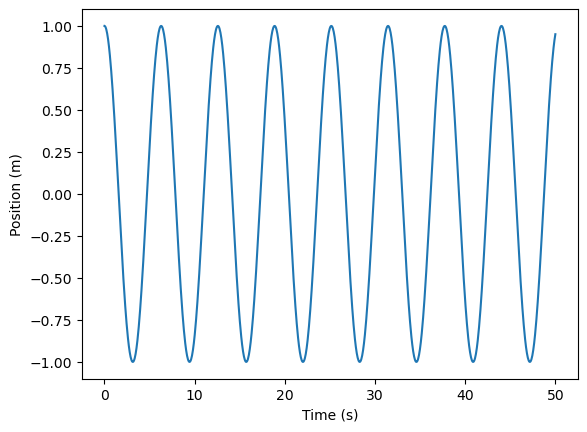

In [ ]:
#Plotting our results
plt.plot(t_array,r_array_ho[:,0])
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.show()

Yes, this matches what I expected, as examining our final general solution of x(t) we can also rewrite this as:
$$x(t)=A\cos{\left(\omega t + \delta\right)},$$
which matches our graph above, specifically with $A=\omega=1$ and $\delta=0$.

#### Step 6: Now graph $dx/dt$ vs. $x$ instead. This is called a *phase space* plot. Interpret the result (do an internet search to understand phase space plots if need be, but your explanations must be in your own words). 

If you would like to make your graph square, you can use: 
`plt.figure(figsize=(#,#))` replacing the #'s with whatever equal dimensions you want. 

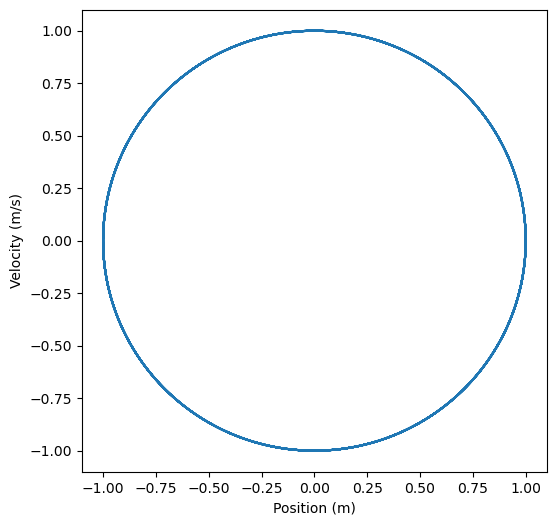

In [ ]:
#Plotting our results
plt.figure(figsize=(6*np.max(r_array_ho[:,0]),6*np.max(r_array_ho[:,1])))
plt.plot(r_array_ho[:,0],r_array_ho[:,1])
plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.show()

This makes a lot of since because of our governing equations. In general I would expect an ellipse, aligned in the $x$ and $y$ axes, where we can manipulate the amplitude by varying either the starting velocity or position, and the ratio between those axes by varying the constant $\omega$.

### Part 2: Variations

Test what happens to your solution when we change some parameters. 

#### Step 1: Increase the amplitude of oscillators by making the initial position larger. Reanalyze the results and plot $x$ vs. $t$ again. What can you say about the oscillations? In particular, comment on the period of oscillations - what do we expect to happen to the period when the amplitude is increased?  

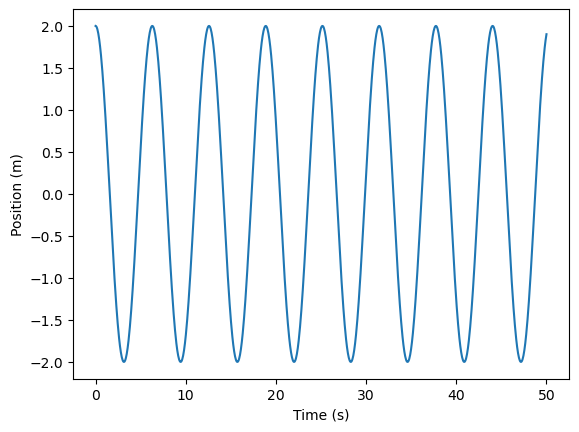

In [ ]:
#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 50
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)
r = np.array([2,0], float) #Initial Condition
r_array = RK4(r,t_array,h,f) #Output // Results

#Plotting our results
plt.plot(t_array,r_array[:,0])
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.show()

We shouldn't expect the period of the oscillations to change, only the amplitude, as our constant $\omega$ is what governs our period (frequency).

#### Step 2: Using the original amplitude, change the initial conditions to be $x = 0$ and $dx/dt = 1$. Analyze the results and plot position vs. time again. What do you notice about the oscillations compared to the previous step and the original in Part 1?

(You may find it helpful to plot the original results from Part 1 simultaneously on the same graph for comparison)

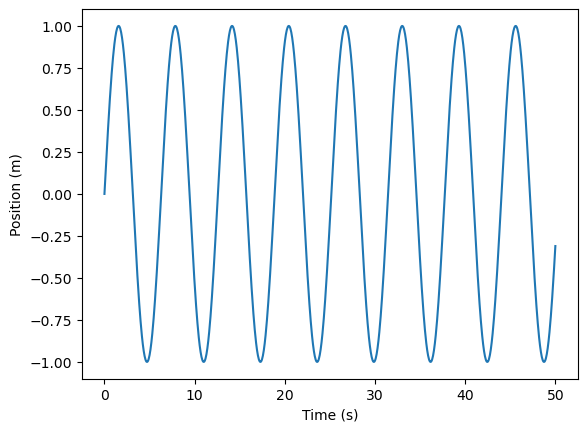

In [ ]:
#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 50
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)
r = np.array([0,1], float) #Initial Condition
r_array = RK4(r,t_array,h,f) #Output // Results

#Plotting our results
plt.plot(t_array,r_array[:,0])
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.show()

Notice that the difference between the two results is only the relative phase of the wave, in particular, our first result was a cosine function and now this result is a sine function. The period and amplitude are the same.

### Part 3: Anharmonic Oscilator 

Let's now analyze the motion of an anharmonic oscillator described by the equations
$$ \frac{d^2x}{dt^2} = -\omega^2 x^3 $$
Again, analyze the case of $\omega = 1$ in the range of $t=0$ to $t=30$. The initial conditions are $x=1$ and $dx/dt = 0$. 

#### Step 1: Make a graph of $x$ vs. $t$ by applying steps 1-5 from part 1 above for this new equation. 
**Hint**: You can/should reuse your `RK4_Multi` function rather than coding it up again, but be sure to complete all 5 steps 

Equations:
\begin{align*}
    \frac{dx}{dt}&=v\\
    \frac{dv}{dt}&=-\omega^2 x^3
\end{align*}

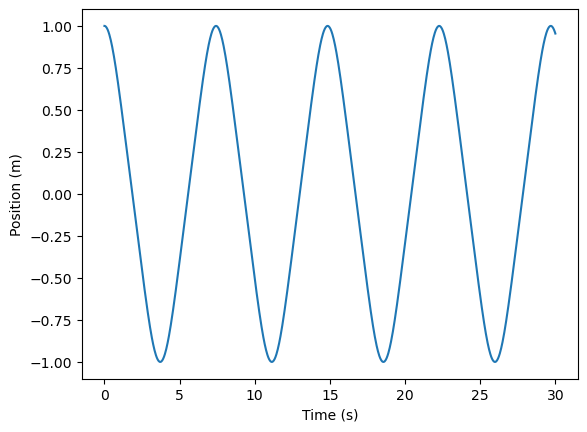

In [ ]:
# Diff. Equation
def f_ah(r,t):
    # r = [x,v] // Input
    x,v = r[0],r[1]
    
    #Differential Equations
    fx = v
    fv = -omega**2 * x**3
    
    #Output // Results
    return np.array([fx,fv], float) 

#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 30
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)
r = np.array([1,0], float) #Initial Conditions
r_array_ah = RK4(r,t_array,h,f_ah) #Output // Results

#Plotting our results
plt.plot(t_array,r_array_ah[:,0])
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.show()

Notice that the main difference between this result and the previous result is that the anharmonic oscillator appears to be more 'spiky' in its behavior than the harmonic oscillator.

#### Step 2: Once again, vary the amplitude to see what happens when we increase the amplitude from $x=1$ to $x=2$ to $x=4$. Plot all three position vs. time graphs on the same graph (be sure to include a legend). What do you notice about an anharmonic oscillator as the amplitude increases? 

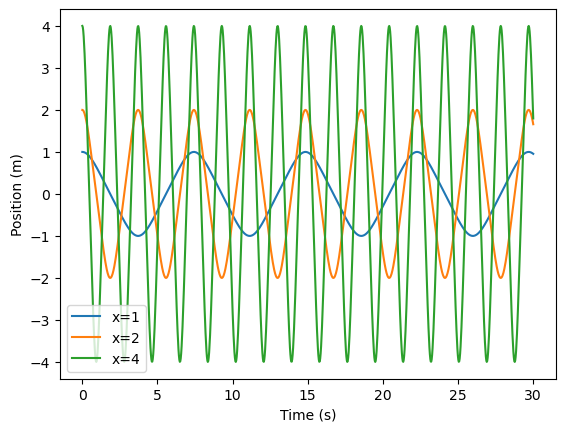

In [ ]:
#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 30
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)

#For loop over different amplitudes // plotting results
for i in [1,2,4]:
    #Initial Condition
    r = np.array([i,0], float) 
    
    #Output//Results
    r_array_ah = RK4(r,t_array,h,f_ah) 
    
    #Plotting Results
    plt.plot(t_array,r_array_ah[:,0])

#Plotting Continued
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.legend(["x=1","x=2","x=4"])
plt.show()

As we increase amplitude we also see an increase in frequency (I believe this increase is linear in terms of amplitude), which is interesting given that in the harmonic oscillator the frequency didn't change when we changed the amplitude. This is probably one of the reasons why the harmonic oscillator is such an important solution, as this unique property is probably key to specific descriptions of physical (or theoretical) phenomena.

#### Step 3: Now graph the *phase space* plot of the anharmonic oscillator. Include the phase space of the harmonic oscillator. In markdown, interpret the result and compare with the harmonic oscillator phase space plot. (Do this for the *original* initial conditions - they need to be the same to properly compare)

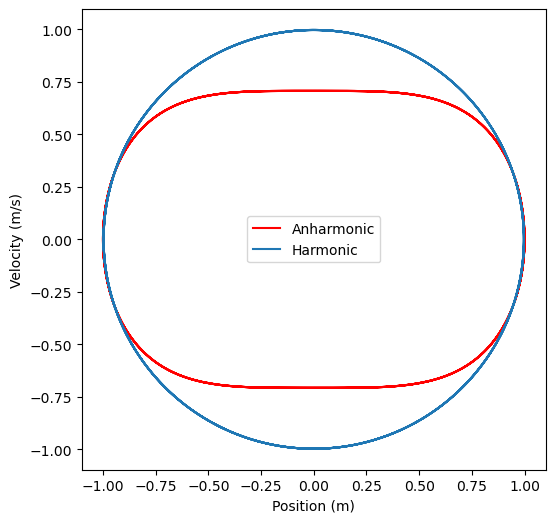

In [110]:
#Constants // Computational set-up
omega = 1
N = 1000
t_i,t_f = 0, 30
h = (t_f-t_i)/N

#Arrays
t_array = np.linspace(t_i,t_f,N)
##Initial Condition
r = np.array([1,0], float)
##Output/Result Arrays
r_array_ah = RK4(r,t_array,h,f_ah) 
r_array_ho = RK4(r,t_array,h,f)

#Plotting our phase space
plt.figure(figsize=(6*np.max(r_array_ho[:,0]),6*np.max(r_array_ho[:,1])))
plt.plot(r_array_ah[:,0],r_array_ah[:,1], "r")
plt.plot(r_array_ho[:,0],r_array_ho[:,1])
plt.legend(["Anharmonic","Harmonic"])
plt.ylabel("Velocity (m/s)")
plt.xlabel("Position (m)")
plt.show()

Interestingly it appears that increasing the power (while keeping the power odd) results in the phase diagram appearing to 'squish' symmetrically along the velocity direction. It is somewhat hard to really get an intuition about what this exactly means, but I imagine that it has something to do with how increasing the power also causes anharmonic oscillators also seem to have a more 'spiky' response at higher powers, meaning that the velocity at which the oscillator travels is at a set velocity for longer before 'turning around' in direction.